In [1]:
import numpy as np 
from matplotlib import pyplot as plt
import sys
import os
from os import path
import h5py
from pprint import pprint as pp
# print(path.join(path.abspath(''), "radiative_shock"))
sys.path.insert(0, "./radiative_shock/")
from nlte_radiative_shock import NLTERadiativeShock

In [2]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16
ev = 1.602176634e-12
kev = 1e3*ev

kev_to_kelvin = kev / boltzmann_constant

In [3]:
print(f"{1e15/kev_to_kelvin:.2e}")

8.62e+07


INFO:RadiativeShock:creating a RadiativeShock calculator...
INFO:RadiativeShock:gamma=1.66667
INFO:RadiativeShock:M0=2
INFO:RadiativeShock:P0=0.0001
INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.45969e-13[g/cc] T=100[K]=8.617333e-06[keV] v=235470[cm/s]
INFO:RadiativeShock:upstream   (shocked, right)  state: rho=1.248126e-12[g/cc] T=207.757[K]=1.790311e-05[keV] v=103021.4[cm/s]
INFO:RadiativeShock:v_shock=34.7631[cm/s]
INFO:RadiativeShock:compression 2.28607
INFO:RadiativeShock:matter ideal gas (gamma=1.66667) dominated compression 2.28576
INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 2.91498
INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=2 while given mach M0=2 err=2.22045e-16
INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock


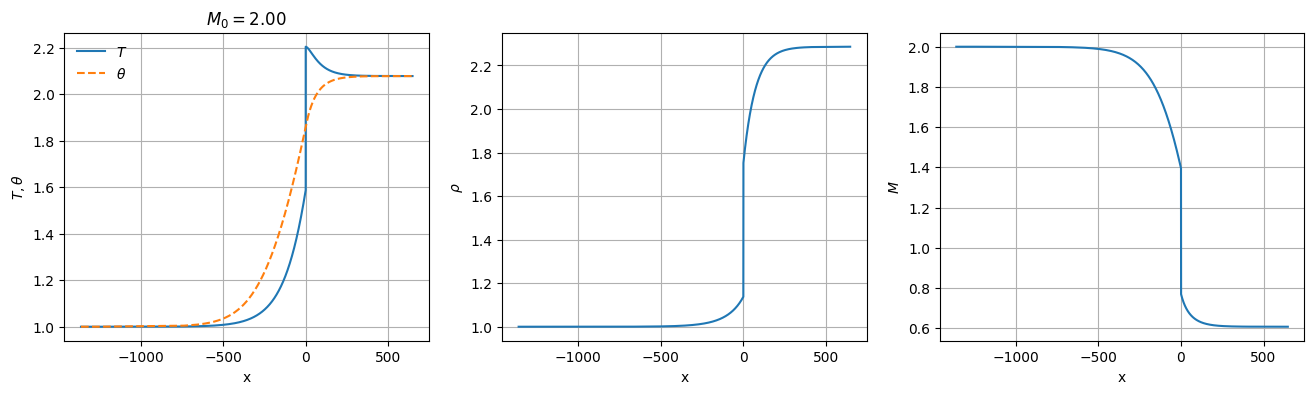

[-1360.92854384 -1247.62395301  -736.21112209 ...   414.0705046
   577.14112588   647.09419896]


In [5]:
Navog = 6.02214076e23
k_boltz = 1.380649e-16
gas_constant = k_boltz*Navog
molar_mass_H = 1.
solver = NLTERadiativeShock(
    M0=2.,
    gamma=5./3.,
    sigma_ross=lambda T,rho:0.848903,
    sigma_abs=lambda T,rho:3.923e-5,
    cv=gas_constant/(5./3.-1.)/molar_mass_H,
    rho_left=5.45969e-13,
    v_left=2.3547e5,
    T_left=100.,
    plot_dimensionless=True,
    eps_nlte_solver=0.5e-4,
).plot_profiles()

<KeysViewHDF5 ['Box', 'Cycle', 'Time', 'rank0', 'rank1', 'rank10', 'rank11', 'rank12', 'rank13', 'rank14', 'rank15', 'rank16', 'rank17', 'rank18', 'rank19', 'rank2', 'rank20', 'rank21', 'rank22', 'rank23', 'rank24', 'rank25', 'rank26', 'rank27', 'rank28', 'rank29', 'rank3', 'rank30', 'rank31', 'rank4', 'rank5', 'rank6', 'rank7', 'rank8', 'rank9']>
<KeysViewHDF5 ['CMx', 'CMy', 'CMz', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_2', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>
num_ranks:  32
num_cells:  512
num_groups:  15


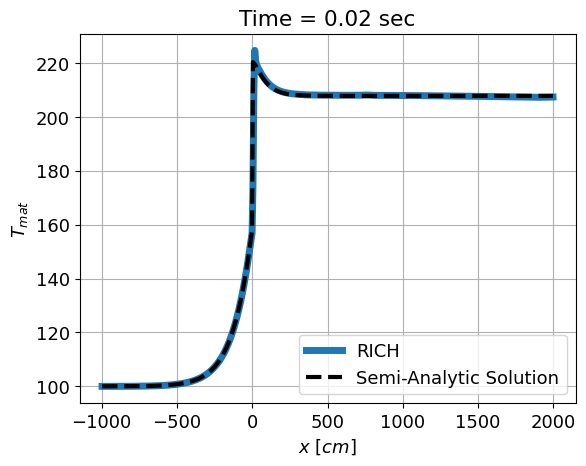

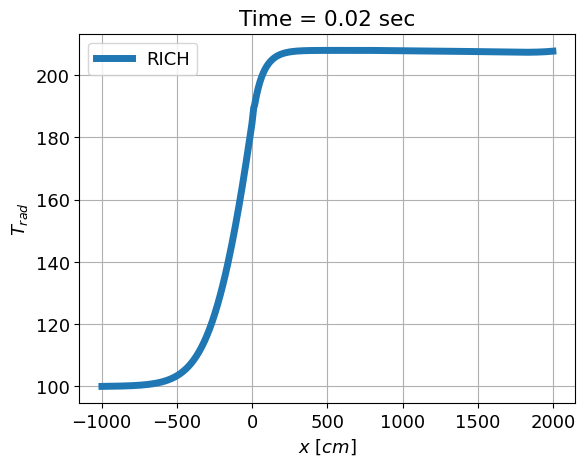

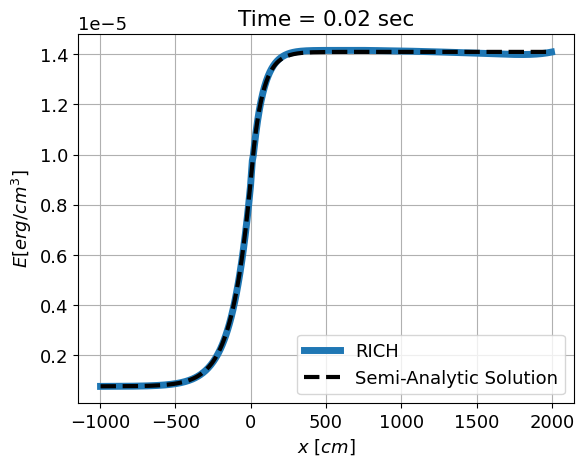

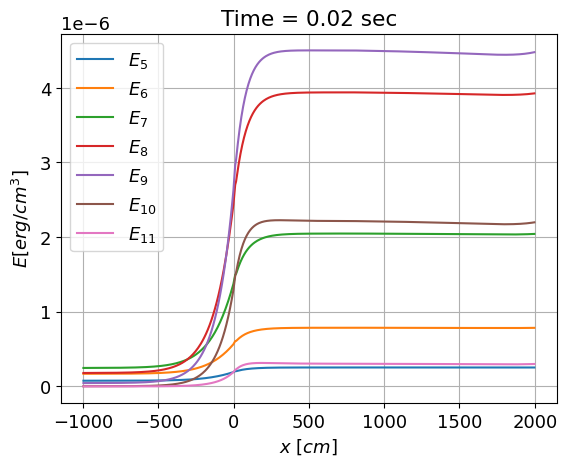

In [7]:
output_files_path = "/home/itamarg/workspace/RICH/output/RadHydroMach2Multigroup"
path_to_final_state = path.join(output_files_path, f"Mach2_final.h5")
# path_to_final_state = path.join(output_files_path, f"Mach2_0.h5")
dir_figs = "Mach2"
os.makedirs(dir_figs, exist_ok=True)

num_cells = None
num_groups = None

with_mpi = True

Tmat = None
time = None
CMx = None

if not with_mpi:
    with h5py.File(path_to_final_state) as h5_file:
        print(h5_file.keys())
        num_cells = len(np.array(h5_file["Temperature"]))
        num_groups = len([key for key in h5_file.keys() if "Eg" in key])

    print("num_cells: ", num_cells)
    print("num_groups: ", num_groups)

    with h5py.File(path_to_final_state) as h5_file:
        Tmat = np.array(h5_file["Temperature"])
        CMx = np.array(h5_file["CMx"])
        time = h5_file["Time"][0]
else:
    with h5py.File(path_to_final_state) as h5_file:
        print(h5_file.keys())
        print(h5_file["rank0"].keys())

        num_ranks = len([key for key in h5_file.keys() if "rank" in key])
        num_groups = len([key for key in h5_file['rank0'].keys() if "Eg" in key])
        
        num_cells = 0
        for i in range(num_ranks):
            num_cells += h5_file[f"rank{i}"]['Temperature'].shape[0]

        print("num_ranks: ", num_ranks)    
        print("num_cells: ", num_cells)
        print("num_groups: ", num_groups)

        time = h5_file['Time'][0]
        Tmat = np.ndarray(shape=(0))
        Erad = np.ndarray(shape=(0))
        CMx =  np.ndarray(shape=(0))
        density  = np.ndarray(shape=(0))
        Eg = [np.ndarray(shape=(0)) for _ in range(num_groups)]
        for i in range(num_ranks):
            num_cells += h5_file[f"rank{i}"]['Temperature'].shape[0]
            Tmat = np.append(Tmat, np.array(h5_file[f"rank{i}"]['Temperature']))
            Erad = np.append(Erad, np.array(h5_file[f"rank{i}"]['Erad']))
            CMx = np.append(CMx, np.array(h5_file[f"rank{i}"]['CMx']))
            density = np.append(density, np.array(h5_file[f"rank{i}"]['Density']))
            for g in range(num_groups):
                Eg[g] = np.append(Eg[g], np.array(h5_file[f"rank{i}"][f"Eg_{g}"]))


Trad = (Erad*density/radiation_constant)**0.25
sol = solver.solve_profiles(time=time, x=CMx)
plt.plot(CMx, Tmat, lw=5, label="RICH")
plt.plot(CMx, sol['temperature'], '--', c='k', lw=3, label="Semi-Analytic Solution")


# plt.xlim(0., 1.5)
# plt.ylim(0.2, 1.0)
plt.grid(True)
plt.xlabel(r"$x\ [cm]$")
plt.ylabel(r"$T_{mat}$")
plt.title(f"Time = {time:.2f} sec")
plt.legend(loc="best")
plt.savefig(path.join(dir_figs, f"Mach2Tmat.png"))
plt.show()
plt.close()

plt.plot(CMx, Trad, lw=5, label="RICH")
# plt.plot(CMx, sol['radiation_temperature'], '--', c='k', lw=3, label="Semi-Analytic Solution")
plt.grid(True)
plt.xlabel(r"$x\ [cm]$")
plt.ylabel(r"$T_{rad}$")
plt.title(f"Time = {time:.2f} sec")
plt.legend(loc="best")
plt.savefig(path.join(dir_figs, f"Mach2Trad.png"))
plt.show()
plt.close()


plt.plot(CMx, Erad*density, lw=5, label="RICH")
plt.plot(CMx, radiation_constant*sol['radiation_temperature']**4, '--', c='k', lw=3, label="Semi-Analytic Solution")
plt.grid(True)
plt.xlabel(r"$x\ [cm]$")
plt.ylabel(r"$E [erg/cm^3]$")
plt.title(f"Time = {time:.2f} sec")
plt.legend(loc="best")
plt.savefig(path.join(dir_figs, f"Mach2Erad.png"))
plt.show()
plt.close()

for g in range(num_groups):
    Eg_cells = Eg[g]*density
    if np.any(Eg_cells > 1e-7):
        plt.plot(CMx, Eg_cells, label=f"$E_{{{g}}}$")

plt.grid(True)
plt.xlabel(r"$x\ [cm]$")
plt.ylabel(r"$E [erg/cm^3]$")
plt.title(f"Time = {time:.2f} sec")
plt.legend(loc="best")
plt.savefig(path.join(dir_figs, f"Mach2Eg.png"))
plt.show()
plt.close()